# **2. Frequency Domain**

The function `parse_dataset_fft()` transforms raw audio files into numerical features using the **Fast Fourier Transform (FFT)**.

Instead of working directly with time-domain signals (waveforms), we convert them into the **frequency domain**, which helps neural networks detect patterns related to pitch, tone, and spectral structure.


The FFT converts the signal from:

* ⏱ Time domain → 🎼 Frequency domain

Now instead of amplitude over time, we have complex frequency coefficients. Each coefficient represents how much of a certain frequency exists in the signal.



### LIBRARIES

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import os
import IPython.display as ipd
import librosa
import soundfile as sf
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras import models
from tensorflow.keras import layers
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
import json
from datetime import datetime

### Data Paths

In [2]:
output_segmented_cats_path = r"C:\Users\Ale\Documents\Lab01\Dataset_Audio\segmented\cats"
output_segmented_dogs_path = r"C:\Users\Ale\Documents\Lab01\Dataset_Audio\segmented\dogs"

## **1. Data Preprocessing**

In [3]:
def parse_dataset_fft(dataset_paths):
    X = []
    y = []

    for index, dataset in enumerate(dataset_paths):
        print(f"[+] Parsing {dataset} data...")

        for fname in os.listdir(dataset):
            wav, sr = librosa.load(os.path.join(dataset, fname), sr=None)

            # Apply FFT
            fft = np.fft.fft(wav)

            magnitude = np.abs(fft)
            magnitude = magnitude[:len(magnitude)//2]

            X.append(magnitude)
            y.append(index)

    return np.array(X), np.array(y)


dataset_paths = [output_segmented_cats_path, output_segmented_dogs_path]
X, y = parse_dataset_fft(dataset_paths)

[+] Parsing C:\Users\Ale\Documents\Lab01\Dataset_Audio\segmented\cats data...


c:\Users\Ale\Documents\Lab01\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[+] Parsing C:\Users\Ale\Documents\Lab01\Dataset_Audio\segmented\dogs data...


In [4]:
print("The length of the data set is: ", len(X))

The length of the data set is:  580


In [5]:
print(len(X[0]))

33075


#### We divide the dataset into training and testing.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [7]:
print("Length of training subset: ", len(X_train))
print("Lenght of testing subset: ", len(X_test))

Length of training subset:  493
Lenght of testing subset:  87


In [8]:
print(X.shape)
print(X_train.shape)


(580, 33075)
(493, 33075)


Text(0.5, 1.0, 'Distribution of classes in the training set')

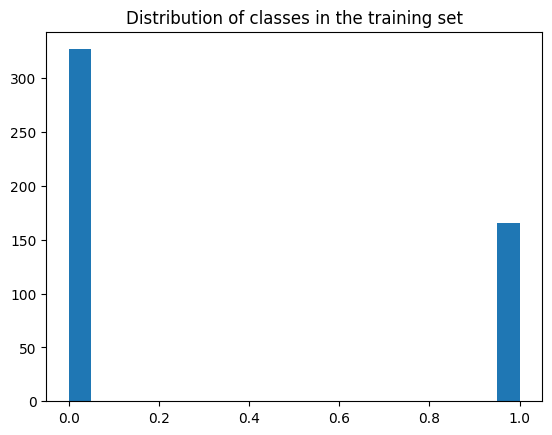

In [9]:
plt.hist(y_train, bins=20)
plt.title("Distribution of classes in the training set")

### **1. Model Construction**

In [10]:
X_train = np.array(X_train)
X_test = np.array(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [19]:
network = models.Sequential()

network.add(layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
network.add(layers.Dense(32, activation='relu'))
network.add(layers.Dense(1, activation='sigmoid'))

network.compile(loss='binary_crossentropy',
                optimizer='adam',
                metrics=['accuracy', 'Precision'])


history = network.fit(X_train, 
                      y_train,
                      batch_size=32,
                      epochs=15, 
                      validation_data=(X_test, y_test))

Epoch 1/15
16/16 [==============================] - 1s 25ms/step - loss: 22.0117 - accuracy: 0.7769 - precision: 0.6556 - val_loss: 10.8599 - val_accuracy: 0.8966 - val_precision: 0.9130
Epoch 2/15
16/16 [==============================] - 0s 12ms/step - loss: 6.0940 - accuracy: 0.8641 - precision: 0.7895 - val_loss: 10.8207 - val_accuracy: 0.8851 - val_precision: 0.8214
Epoch 3/15
16/16 [==============================] - 0s 11ms/step - loss: 1.8188 - accuracy: 0.9067 - precision: 0.8371 - val_loss: 8.0417 - val_accuracy: 0.8851 - val_precision: 0.8214
Epoch 4/15
16/16 [==============================] - 0s 11ms/step - loss: 1.3091 - accuracy: 0.9554 - precision: 0.9390 - val_loss: 6.4117 - val_accuracy: 0.8736 - val_precision: 0.9048
Epoch 5/15
16/16 [==============================] - 0s 11ms/step - loss: 2.8257 - accuracy: 0.8986 - precision: 0.8021 - val_loss: 21.2509 - val_accuracy: 0.8161 - val_precision: 0.8750
Epoch 6/15
16/16 [==============================] - 0s 11ms/step - loss

In [20]:
y_pred_probs = network.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

3/3 [==============================] - 0s 4ms/step


In [21]:
y_test = np.array(y_test).flatten()

### **RESULTS**

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", tf.keras.metrics.AUC()(y_test, y_pred_probs).numpy() )

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.896551724137931
Precision: 0.9523809523809523
Recall: 0.7142857142857143
F1 Score: 0.8163265306122449
AUC: 0.84352297

Confusion Matrix:
[[58  1]
 [ 8 20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93        59
           1       0.95      0.71      0.82        28

    accuracy                           0.90        87
   macro avg       0.92      0.85      0.87        87
weighted avg       0.90      0.90      0.89        87



In [23]:
from IPython.display import display, HTML

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = tf.keras.metrics.AUC()(y_test, y_pred_probs).numpy()

display(HTML(f"""
<div style="
    background-color:#ffe6f2;
    padding:15px;
    border-radius:10px;
    font-family:Arial;
    width:400px">
    <h3 style="color:#d63384;"> Model Metrics </h3>
    <p><b>Accuracy:</b> {acc:.3f}</p>
    <p><b>Precision:</b> {prec:.3f}</p>
    <p><b>Recall:</b> {rec:.3f}</p>
    <p><b>F1 Score:</b> {f1:.3f}</p>
    <p><b>AUC:</b> {auc:.3f}</p>
</div>
"""))


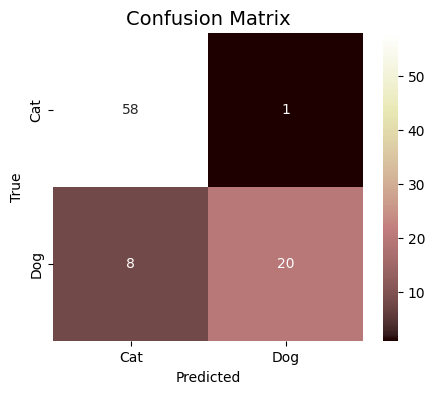

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="pink",
            xticklabels=["Cat", "Dog"],
            yticklabels=["Cat", "Dog"])

plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [25]:
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

df_report.style.background_gradient(cmap="RdPu")

,precision,recall,f1-score,support
0,0.878788,0.983051,0.928000,59.000000
1,0.952381,0.714286,0.816327,28.000000
accuracy,0.896552,0.896552,0.896552,0.896552
macro avg,0.915584,0.848668,0.872163,87.000000
weighted avg,0.902473,0.896552,0.892059,87.000000


In [26]:
model_name = "2. MLP"
representation = "Frequency Domain"
save_dir_path = "model_metrics"

metrics_dict = {"model": model_name,
        "representation": representation,
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1_score": float(f1),
        "auc": float(auc),
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }

if not os.path.exists(save_dir_path):
    os.makedirs(save_dir_path, exist_ok=True)

file_path = os.path.join(save_dir_path, f"{model_name}_{representation}.json")

with open(file_path, "w") as f: json.dump(metrics_dict, f, indent=4)
print(f"Metrics saved to: {file_path}")

Metrics saved to: model_metrics\2. MLP_Frequency Domain.json


### **Conclussions**

Accuracy: 0.85 → The model correctly classifies 85% of the samples.

This indicates stable and reliable classification.